# C0 Classifier Performance\n\nStraight-to-the-point evaluation of the **C0 classifiers** on the three tasks they were trained for, for both dataset families:\n\n- **CheXpert** (`C0_custom`) &mdash; cardiomegaly, effusion, pneumothorax\n- **MedMNIST / ChestMNIST** (`C0_medmnist`) &mdash; same three tasks\n\nFor each classifier we read the prediction CSVs already produced by the `c0_*_predictions*` scripts (no inference is re-run here). Predictions use the Youden-J threshold stored in each model's `threshold.txt`.\n\n## ⚠️ Two different splits &mdash; do not confuse the C0 and C2 training sets\n\nThe prediction CSVs are named `{split}_c0_{task}.csv`, where `split` refers to **C0's own train/val/test split**, *not* C2's:\n\n| CSV | what it is |\n|-----|------------|\n| `train_c0_*` | C0's predictions on the images **C0 was trained on** (fit data → optimistic; C2 never uses these) |\n| `val_c0_*`  | C0's predictions on images **held out from C0 training** |\n| `test_c0_*` | (MedMNIST only) C0's predictions on the ChestMNIST test split |\n\n**C2's training data is built from the split C0 did _not_ train on** (verified against `c2_data.csv` on disk):\n\n- **CheXpert**: `c2_data.csv` = 100% of `val_c0` rows → **C2 learns from `val_c0`**.\n- **MedMNIST**: `c2_data.csv` = the `test_c0` split → **C2 learns from `test_c0`**.\n\nC2 then splits that pool *again* with its own K-fold. So the *\"errors C2 can learn from\"* are C0's mistakes on this **C2-source split**, listed per family in `C2_SOURCE_SPLIT` below — **not** on `train_c0` (where C0's errors are artificially low because it was fit to those rows, and which C2 never sees).\n\n```\nCheXpert train.csv\n  └─ 50/50 patient split (seed 42)\n       ├─ c0_train_split ─► C0 TRAINED here    ─► train_c0_*  (fit data)\n       └─ c0_val_split   ─► C0 val (unseen)    ─► val_c0_*   ─► c2_data.csv ─► C2's own K-fold\n```\n\nThis notebook reports per-class metrics on **all** available splits (for context), but computes the error counts **only on the C2-source split**.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_recall_fscore_support,
    confusion_matrix,
)

pd.set_option('display.float_format', lambda v: f'{v:.4f}')

RESULTS_DIR = '/work3/s251710/thesis_results'
TASKS = ['cardiomegaly', 'effusion', 'pneumothorax']

# family -> subdir under RESULTS_DIR
FAMILIES = {
    'chexpert': 'C0_custom',
    'medmnist': 'C0_medmnist',
}

# The prediction CSVs are named {split}_c0_{task}.csv, where `split` is C0's OWN
# split. CheXpert has train/val; MedMNIST has train/val/test. Auto-detect these.
CANDIDATE_SPLITS = ['train', 'val', 'test']

# Which C0 split becomes C2's data pool, per family (see intro; verified against
# c2_data.csv on disk). The "errors C2 can learn from" are counted on THIS split
# only -- NOT on train_c0 (C0's own fit data, which C2 never sees).
C2_SOURCE_SPLIT = {
    'chexpert': 'val',    # c2_data.csv == 100% of val_c0 rows
    'medmnist': 'test',   # c2_data.csv == the ChestMNIST test split
}

## Load whatever prediction CSVs exist

This cell scans `RESULTS_DIR` and loads every `{split}_c0_{task}.csv` it finds, together with the saved threshold. Missing models are simply skipped and listed, so the notebook works now and fills itself in as you finish training the remaining classifiers.

In [2]:
def read_threshold(model_dir):
    p = os.path.join(model_dir, 'threshold.txt')
    if not os.path.exists(p):
        return None
    with open(p) as f:
        return float(f.read().strip())


# preds[(family, task, split)] = DataFrame; thresholds[(family, task)] = float
preds = {}
thresholds = {}
missing = []

for family, subdir in FAMILIES.items():
    for task in TASKS:
        model_dir = os.path.join(RESULTS_DIR, subdir, task)
        thr = read_threshold(model_dir)
        if thr is not None:
            thresholds[(family, task)] = thr
        found_any = False
        for split in CANDIDATE_SPLITS:
            csv = os.path.join(model_dir, f'{split}_c0_{task}.csv')
            if os.path.exists(csv):
                # only need labels + probs; drop the heavy embedding columns
                df = pd.read_csv(csv, usecols=lambda c: not c.startswith('emb_'))
                preds[(family, task, split)] = df
                found_any = True
        if not found_any:
            missing.append((family, task))

print('Loaded prediction sets:')
for (family, task, split), df in sorted(preds.items()):
    thr = thresholds.get((family, task))
    thr_str = f'{thr:.4f}' if thr is not None else '  n/a '
    print(f'  {family:8s} {task:13s} {split:5s}  n={len(df):>7,}  thr={thr_str}')

if missing:
    print('\nNot yet available (no CSVs found):')
    for family, task in missing:
        print(f'  {family:8s} {task}')

Loaded prediction sets:
  chexpert cardiomegaly  train  n= 18,826  thr=0.6839
  chexpert cardiomegaly  val    n= 19,290  thr=0.6839
  chexpert effusion      train  n= 60,141  thr=0.5634
  chexpert effusion      val    n= 61,442  thr=0.5634
  chexpert pneumothorax  train  n= 37,873  thr=0.2982
  chexpert pneumothorax  val    n= 37,916  thr=0.2982
  medmnist effusion      test   n= 22,433  thr=0.0908
  medmnist effusion      train  n= 78,468  thr=0.0908
  medmnist effusion      val    n= 11,219  thr=0.0908

Not yet available (no CSVs found):
  medmnist cardiomegaly
  medmnist pneumothorax


## Per-model metrics

`prob`/`true` are always present. We recompute `pred` from the saved threshold (rather than trusting the `pred` column) so the whole notebook uses one consistent rule. Metrics are reported for each class.

In [3]:
def metrics_for(df, thr):
    y = df['true'].astype(int).values
    p = df['prob'].values
    yhat = (p > thr).astype(int)

    auc = roc_auc_score(y, p) if len(np.unique(y)) > 1 else np.nan
    acc = accuracy_score(y, yhat)
    # per-class precision/recall/f1 (label order [0, 1] = [neg, pos])
    prec, rec, f1, support = precision_recall_fscore_support(
        y, yhat, labels=[0, 1], zero_division=0)

    return {
        'n': len(df),
        'prevalence': y.mean(),
        'AUC': auc,
        'accuracy': acc,
        'neg_support': support[0], 'neg_precision': prec[0], 'neg_recall': rec[0], 'neg_f1': f1[0],
        'pos_support': support[1], 'pos_precision': prec[1], 'pos_recall': rec[1], 'pos_f1': f1[1],
    }


rows = []
for (family, task, split), df in preds.items():
    thr = thresholds.get((family, task))
    if thr is None:
        continue
    m = metrics_for(df, thr)
    m.update({'family': family, 'task': task, 'split': split})
    rows.append(m)

metrics_df = pd.DataFrame(rows).set_index(['family', 'task', 'split']).sort_index()
metrics_df

n  prevalence    AUC  accuracy  neg_support  \
family   task         split                                                    
chexpert cardiomegaly train  18826      0.7065 0.9505    0.8785         5525   
                      val    19290      0.7102 0.9268    0.8530         5591   
         effusion     train  60141      0.7041 0.9729    0.9248        17797   
                      val    61442      0.7136 0.9566    0.9109        17599   
         pneumothorax train  37873      0.2548 0.9072    0.8283        28222   
                      val    37916      0.2584 0.8182    0.7589        28119   
medmnist effusion     test   22433      0.1228 0.8793    0.8045        19679   
                      train  78468      0.1180 0.9109    0.8230        69207   
                      val    11219      0.1152 0.8757    0.8007         9927   

                             neg_precision  neg_recall  neg_f1  pos_support  \
family   task         split                                                   
chexpert cardiomegaly train         0.7360      0.9137  0.8152        13301   
                      val           0.6973      0.8710  0.7746        13699   
         effusion     train         0.8388      0.9233  0.8790        42344   
                      val           0.8131      0.8947  0.8520        43843   
         pneumothorax train         0.9340      0.8280  0.8778         9651   
                      val           0.8801      0.7814  0.8278         9797   
medmnist effusion     test          0.9676      0.8040  0.8783         2754   
                      train         0.9765      0.8190  0.8909         9261   
                      val           0.9667      0.8024  0.8769         1292   

                             pos_precision  pos_recall  pos_f1  
family   task         split                                     
chexpert cardiomegaly train         0.9601      0.8638  0.9095  
                      val           0.9414      0.8457  0.8910  
         effusion     train         0.9663      0.9254  0.9454  
                      val           0.9559      0.9175  0.9363  
         pneumothorax train         0.6224      0.8290  0.7110  
                      val           0.5254      0.6944  0.5982  
medmnist effusion     test          0.3658      0.8079  0.5036  
                      train         0.3868      0.8529  0.5322  
                      val           0.3416      0.7879  0.4766

### Compact per-class summary

The same numbers, reshaped so each row is one classifier/split and columns group by class &mdash; easiest way to eyeball where a model is weak (usually recall on the positive/minority class).

In [4]:
summary = metrics_df[[
    'n', 'prevalence', 'AUC', 'accuracy',
    'pos_recall', 'pos_precision', 'pos_f1',
    'neg_recall', 'neg_precision', 'neg_f1',
]].copy()
summary.columns = [
    'n', 'prev', 'AUC', 'acc',
    'pos_rec', 'pos_prec', 'pos_f1',
    'neg_rec', 'neg_prec', 'neg_f1',
]
summary

n   prev    AUC    acc  pos_rec  pos_prec  \
family   task         split                                                  
chexpert cardiomegaly train  18826 0.7065 0.9505 0.8785   0.8638    0.9601   
                      val    19290 0.7102 0.9268 0.8530   0.8457    0.9414   
         effusion     train  60141 0.7041 0.9729 0.9248   0.9254    0.9663   
                      val    61442 0.7136 0.9566 0.9109   0.9175    0.9559   
         pneumothorax train  37873 0.2548 0.9072 0.8283   0.8290    0.6224   
                      val    37916 0.2584 0.8182 0.7589   0.6944    0.5254   
medmnist effusion     test   22433 0.1228 0.8793 0.8045   0.8079    0.3658   
                      train  78468 0.1180 0.9109 0.8230   0.8529    0.3868   
                      val    11219 0.1152 0.8757 0.8007   0.7879    0.3416   

                             pos_f1  neg_rec  neg_prec  neg_f1  
family   task         split                                     
chexpert cardiomegaly train  0.9095   0.9137    0.7360  0.8152  
                      val    0.8910   0.8710    0.6973  0.7746  
         effusion     train  0.9454   0.9233    0.8388  0.8790  
                      val    0.9363   0.8947    0.8131  0.8520  
         pneumothorax train  0.7110   0.8280    0.9340  0.8778  
                      val    0.5982   0.7814    0.8801  0.8278  
medmnist effusion     test   0.5036   0.8040    0.9676  0.8783  
                      train  0.5322   0.8190    0.9765  0.8909  
                      val    0.4766   0.8024    0.9667  0.8769

## Errors C2 can learn from &mdash; coverage on the **C2-source split**

C2 is trained to spot where C0 went wrong, so the relevant signal is C0's mistakes on the split that actually becomes C2's data pool (`val_c0` for CheXpert, `test_c0` for MedMNIST &mdash; see `C2_SOURCE_SPLIT`). **Counted here, not on `train_c0`** &mdash; C0's errors on its own fit data are artificially low and C2 never sees those rows.

- **FN (false negative)** &mdash; a true positive C0 called negative (missed disease).
- **FP (false positive)** &mdash; a true negative C0 called positive (false alarm).

Each cell is shown both as a **count** and as a **percentage of the whole set** (the `_%` columns), so you can read off directly **how much coverage** C2 has in each category. `correct_% + error_% = 100%`; `error_%` is the share of the set C2 has as *positive* (error) examples to learn from.

In [5]:
# Count C0 errors on the C2-SOURCE split (val for chexpert, test for medmnist),
# i.e. the pool C2 actually trains on -- not train_c0.
# Every cell is also expressed as a PERCENTAGE of the whole set, so you can read
# off directly how much coverage C2 has in each category.
err_rows = []
for family, task in sorted({(f, t) for (f, t, s) in preds}):
    split = C2_SOURCE_SPLIT[family]
    key = (family, task, split)
    thr = thresholds.get((family, task))
    if key not in preds or thr is None:
        continue
    df = preds[key]
    n = len(df)
    y = df['true'].astype(int).values
    yhat = (df['prob'].values > thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, yhat, labels=[0, 1]).ravel()
    n_err = fp + fn
    n_correct = tp + tn
    err_rows.append({
        'family': family, 'task': task, 'c2_split': split,
        'n': n,
        # raw counts
        'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn,
        'correct': n_correct, 'errors': n_err,
        # coverage: share of the WHOLE set in each cell (these sum to 100%)
        'correct_%': 100 * n_correct / n,
        'error_%': 100 * n_err / n,
        'TP_%': 100 * tp / n, 'TN_%': 100 * tn / n,
        'FP_%': 100 * fp / n, 'FN_%': 100 * fn / n,
    })

errors_df = pd.DataFrame(err_rows).set_index(['family', 'task']).sort_index()

# show percentages with 1 decimal, counts as integers
pct_cols = [c for c in errors_df.columns if c.endswith('%')]
fmt = {c: '{:.1f}%'.format for c in pct_cols}
errors_df.style.format(fmt) if hasattr(errors_df, 'style') else errors_df

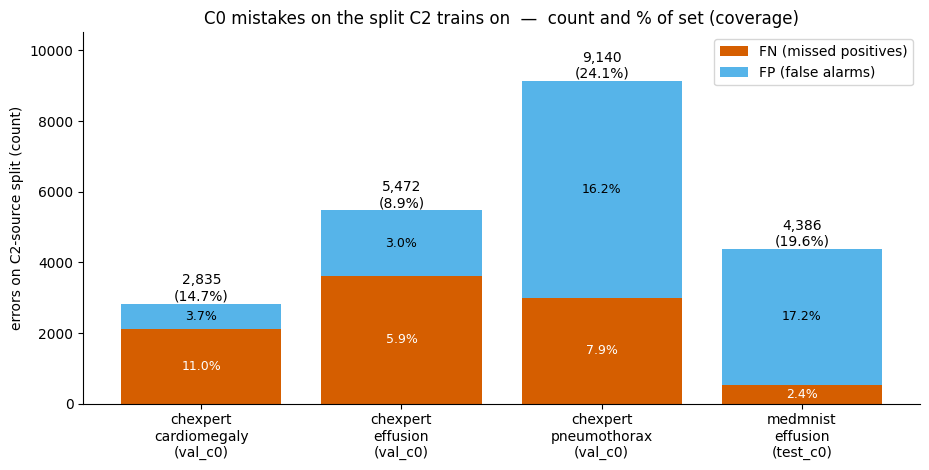

In [6]:
# FP vs FN counts on the C2-source split, per classifier.
# Each bar is annotated with the total error COUNT and its % of the whole set
# (= how much of the data C2 gets as error examples to learn from).
if not errors_df.empty:
    plot_df = errors_df.reset_index()
    plot_df['label'] = plot_df['family'] + '\n' + plot_df['task'] + '\n(' + plot_df['c2_split'] + '_c0)'
    x = np.arange(len(plot_df))

    fig, ax = plt.subplots(figsize=(1.6 * len(plot_df) + 3, 4.8))
    ax.bar(x, plot_df['FN'], label='FN (missed positives)', color='#D55E00')
    ax.bar(x, plot_df['FP'], bottom=plot_df['FN'], label='FP (false alarms)', color='#56B4E9')

    for xi, row in plot_df.iterrows():
        # error count + share of the set on top of each bar
        ax.text(xi, row['errors'], f"{row['errors']:,}\n({row['error_%']:.1f}%)",
                ha='center', va='bottom', fontsize=10)
        # per-segment share inside the bars, when large enough to fit
        if row['FN_%'] >= 2:
            ax.text(xi, row['FN'] / 2, f"{row['FN_%']:.1f}%", ha='center', va='center',
                    fontsize=9, color='white')
        if row['FP_%'] >= 2:
            ax.text(xi, row['FN'] + row['FP'] / 2, f"{row['FP_%']:.1f}%", ha='center',
                    va='center', fontsize=9, color='black')

    ax.set_xticks(x)
    ax.set_xticklabels(plot_df['label'])
    ax.set_ylabel('errors on C2-source split (count)')
    ax.set_title('C0 mistakes on the split C2 trains on  —  count and % of set (coverage)')
    ax.margins(y=0.15)
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()
else:
    print('No C2-source-split predictions loaded yet.')

## Per-class confusion matrices (C2-source split)\n\nThe full breakdown behind the error counts, one small confusion matrix per available classifier, on the split C2 actually trains on.

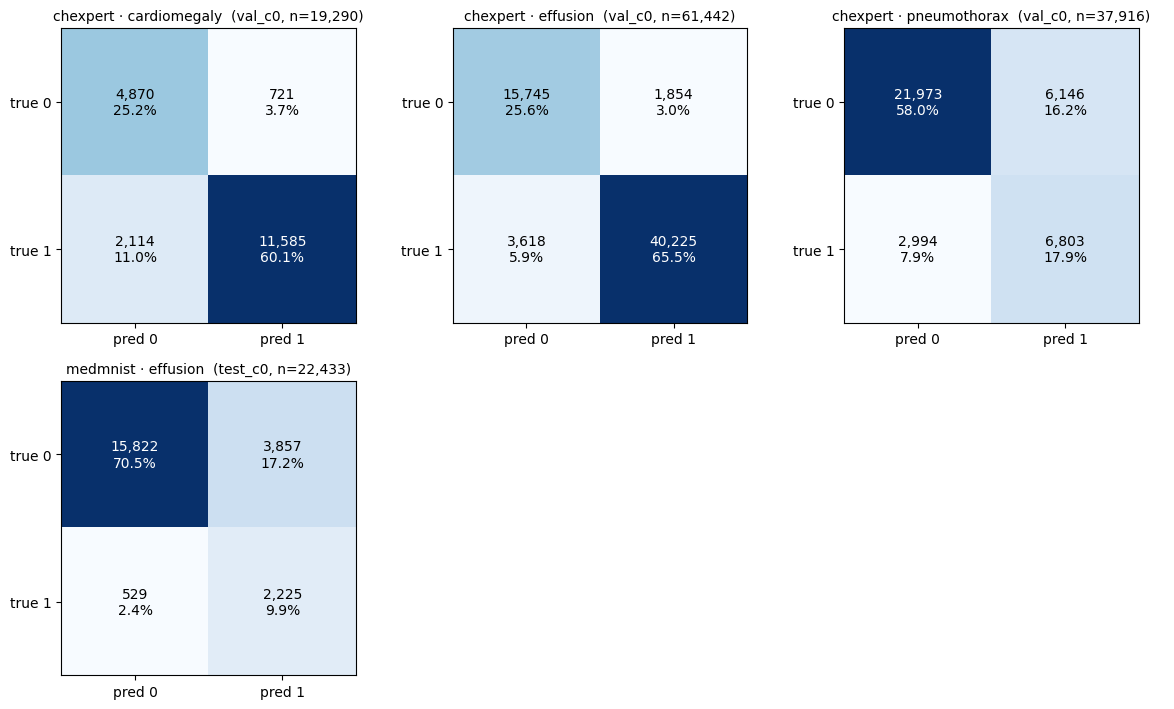

In [7]:
# Confusion matrices on the C2-source split. Each cell shows count + % of the set.
c2_keys = [(f, t, C2_SOURCE_SPLIT[f]) for (f, t, s) in preds
           if s == C2_SOURCE_SPLIT[f] and (f, t) in thresholds]
c2_keys = sorted(set(c2_keys))
if c2_keys:
    ncol = 3
    nrow = int(np.ceil(len(c2_keys) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4 * ncol, 3.6 * nrow), squeeze=False)

    for ax, (family, task, split) in zip(axes.ravel(), c2_keys):
        df = preds[(family, task, split)]
        thr = thresholds[(family, task)]
        y = df['true'].astype(int).values
        yhat = (df['prob'].values > thr).astype(int)
        cm = confusion_matrix(y, yhat, labels=[0, 1])
        cm_pct = 100 * cm / cm.sum()

        ax.imshow(cm, cmap='Blues')
        for (i, j), v in np.ndenumerate(cm):
            ax.text(j, i, f'{v:,}\n{cm_pct[i, j]:.1f}%', ha='center', va='center',
                    color='white' if v > cm.max() / 2 else 'black', fontsize=10)
        ax.set_title(f'{family} · {task}  ({split}_c0, n={cm.sum():,})', fontsize=10)
        ax.set_xticks([0, 1]); ax.set_xticklabels(['pred 0', 'pred 1'])
        ax.set_yticks([0, 1]); ax.set_yticklabels(['true 0', 'true 1'])

    for ax in axes.ravel()[len(c2_keys):]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print('No C2-source-split predictions loaded yet.')

## ROC curves per task

One panel per task, overlaying the available splits/families. Quick visual on separability independent of the chosen threshold.

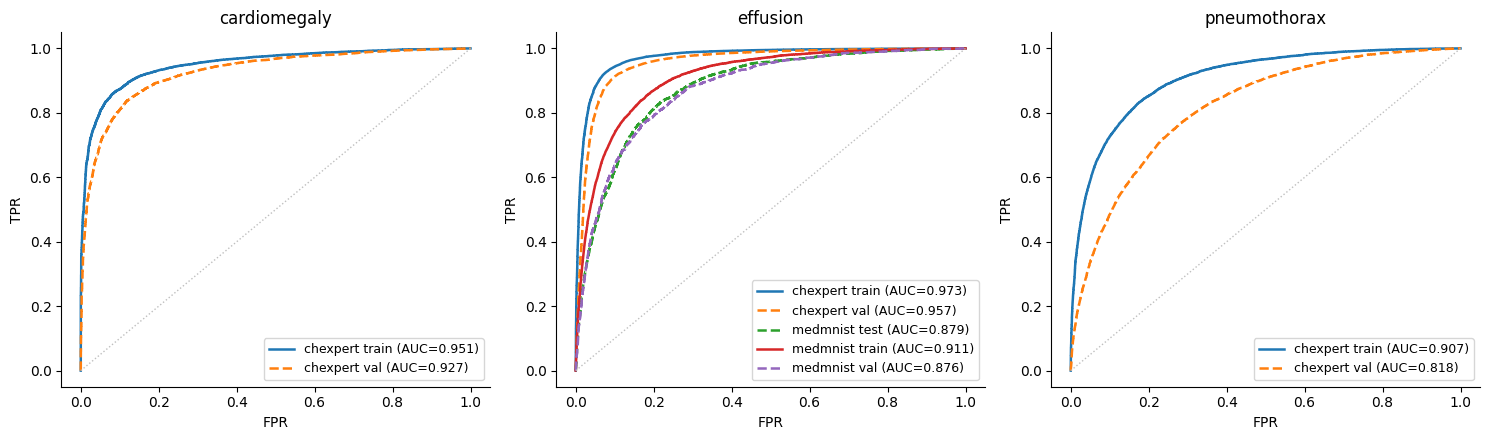

In [8]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, len(TASKS), figsize=(5 * len(TASKS), 4.5), squeeze=False)
for ax, task in zip(axes[0], TASKS):
    plotted = False
    for (family, t, split), df in sorted(preds.items()):
        if t != task:
            continue
        y = df['true'].astype(int).values
        if len(np.unique(y)) < 2:
            continue
        fpr, tpr, _ = roc_curve(y, df['prob'].values)
        auc = roc_auc_score(y, df['prob'].values)
        ls = '-' if split == 'train' else '--'
        ax.plot(fpr, tpr, ls, lw=1.8, label=f'{family} {split} (AUC={auc:.3f})')
        plotted = True
    ax.plot([0, 1], [0, 1], color='#BFBFBF', ls=':', lw=1.0)
    ax.set_title(task)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.spines[['top', 'right']].set_visible(False)
    if plotted:
        ax.legend(fontsize=9)
plt.tight_layout()
plt.show()